# Midterm Project 1 – Model 1: Simple CNN (tự thiết kế)

**Nhóm G8 – AI66A – DNN**

Notebook này thực hiện các yêu cầu của đề midterm cho **Model 1**:

1. **Tiền xử lý dữ liệu**: làm sạch (file lỗi, ảnh trùng, rò rỉ giữa các tập), chuẩn hóa (normalize) và tăng cường dữ liệu (augmentation).
2. **Thiết kế CNN đơn giản** gồm các lớp *convolutional*, *pooling* và *fully connected*.
3. **Huấn luyện và đánh giá** bằng các metric phù hợp (Accuracy, Precision, Recall, F1, Confusion Matrix).

> Bài toán: **phân loại ảnh (image classification)**. Dữ liệu có cấu trúc `train / val / test / <tên_lớp> / ảnh`, đúng với script `extract_data/sample_dataset.py` trong repo.

**Mục lục**
1. Cấu hình & thư viện
2. Khám phá và làm sạch dữ liệu
3. Tiền xử lý: normalize + augmentation
4. Xây dựng Model 1 (Simple CNN)
5. Huấn luyện
6. Đánh giá trên tập test
7. Lưu kết quả để so sánh với Model 2 và Model 3

## 1. Cấu hình & thư viện

In [ ]:
# !pip install torch matplotlib torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 14.9 MB/s  0:00:00 eta 0:00:01
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/554.6 MB 2.1 MB/s eta 0:04:14
ERROR: Exception:
Traceback (most recent call last):
  File "/home/pc/miniconda3/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/home/pc/miniconda3/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "/home/pc/miniconda3/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "/home/pc/miniconda3/lib/python3.13/site-packages/pip/_vendor/cachecontrol/filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "/home/pc/miniconda3/lib/python3.13/http/clien

In [12]:
# Gỡ bản cũ
!pip3 uninstall torch torchvision torchaudio -y

# Cài lại bản hỗ trợ CUDA 12.1 (phổ biến nhất hiện nay)
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 28.6 MB/s  0:00:25:00:0100:01
ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


In [1]:
import os, json, random, hashlib, time, copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

print("PyTorch:", torch.__version__)
print(torch.cuda.is_available())

PyTorch: 2.5.1+cu121
True


In [2]:
# ============ CẤU HÌNH (chỉnh ở đây) ============
SEED         = 42
IMG_SIZE     = 128        # ảnh được resize về IMG_SIZE x IMG_SIZE
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 6          # early stopping: dừng nếu val_loss không cải thiện sau PATIENCE epoch
NUM_WORKERS  = 2
USE_CLASS_WEIGHTS = True  # dùng trọng số lớp nếu dữ liệu mất cân bằng

# Thư mục dữ liệu: ưu tiên data/cut (bản 10.000 ảnh), nếu không có thì dùng data/raw.
# Trên Colab/Kaggle có thể gán trực tiếp, ví dụ: DATA_DIR = Path("/content/data/cut")
CANDIDATES = [Path("data/cut"), Path("../data/cut"), Path("data/raw"), Path("../data/raw")]
DATA_DIR = next((p for p in CANDIDATES if (p / "train").is_dir()), None)
assert DATA_DIR is not None, "Không tìm thấy thư mục dữ liệu. Hãy gán DATA_DIR thủ công."

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print("Dữ liệu :", DATA_DIR.resolve())
print("Thiết bị:", DEVICE)

Dữ liệu : /home/pc/AAA/project/deepnn/G8_AI66A_DNN/data/cut
Thiết bị: cuda


## 2. Khám phá và làm sạch dữ liệu

Các bước làm sạch:
- Liệt kê ảnh theo từng tập (`train`, `val`, `test`) và từng lớp.
- Phát hiện **file ảnh hỏng / không đọc được**.
- Phát hiện **ảnh trùng lặp** (cùng nội dung, so bằng MD5). Ảnh trùng giữa các tập gây **rò rỉ dữ liệu (data leakage)** làm kết quả đánh giá cao giả tạo, nên ta giữ lại ảnh ở tập có ưu tiên cao hơn (`test` > `val` > `train`) và loại bản trùng ở tập thấp hơn.

In [3]:
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".ppm", ".pgm", ".tif", ".tiff", ".webp"}
SPLITS = ["train", "val", "test"]

CLASS_NAMES = sorted(p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f"Số lớp: {NUM_CLASSES} -> {CLASS_NAMES}")

def list_split(split):
    items = []
    for c in CLASS_NAMES:
        for p in sorted((DATA_DIR / split / c).rglob("*")):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                items.append((p, CLASS_TO_IDX[c]))
    return items

raw_samples = {s: list_split(s) for s in SPLITS}

summary = pd.DataFrame({s: Counter(CLASS_NAMES[y] for _, y in raw_samples[s]) for s in SPLITS}).fillna(0).astype(int)
summary["total"] = summary.sum(axis=1)
summary.loc["TỔNG"] = summary.sum()
summary

Số lớp: 4 -> ['CNV', 'DME', 'DRUSEN', 'NORMAL']


,train,val,test,total
CNV,240,69,34,343
DME,74,21,11,106
DRUSEN,57,16,8,81
NORMAL,329,94,47,470
TỔNG,700,200,100,1000


In [4]:
def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

def is_valid_image(path):
    try:
        with Image.open(path) as im:
            im.verify()                      # kiểm tra cấu trúc file
        with Image.open(path) as im:
            im.convert("RGB").load()         # đảm bảo giải mã được hoàn toàn
        return True
    except Exception:
        return False

# 1) Loại file hỏng
corrupt, valid = [], {s: [] for s in SPLITS}
for s in SPLITS:
    for p, y in raw_samples[s]:
        if is_valid_image(p):
            valid[s].append((p, y))
        else:
            corrupt.append(p)
print(f"File ảnh hỏng: {len(corrupt)}")
for p in corrupt[:10]: print("  -", p)

File ảnh hỏng: 0


In [5]:
# 2) Loại ảnh trùng lặp (trong cùng tập và giữa các tập). Ưu tiên: test > val > train
seen_hash = {}
clean = {s: [] for s in SPLITS}
dup_count = Counter()
for s in ["test", "val", "train"]:
    for p, y in valid[s]:
        h = md5_of(p)
        if h in seen_hash:
            dup_count[(s, seen_hash[h])] += 1       # (tập bị loại, tập đã giữ bản gốc)
            continue
        seen_hash[h] = s
        clean[s].append((p, y))

print("Ảnh trùng bị loại:", sum(dup_count.values()))
for (drop_in, kept_in), n in dup_count.items():
    print(f"  - {n} ảnh ở '{drop_in}' trùng với ảnh ở '{kept_in}'")

clean_summary = pd.DataFrame({s: Counter(CLASS_NAMES[y] for _, y in clean[s]) for s in SPLITS}).fillna(0).astype(int)
clean_summary["total"] = clean_summary.sum(axis=1)
clean_summary.loc["TỔNG"] = clean_summary.sum()
print("\nSau khi làm sạch:")
clean_summary

Ảnh trùng bị loại: 0

Sau khi làm sạch:


,train,val,test,total
CNV,240,69,34,343
DME,74,21,11,106
DRUSEN,57,16,8,81
NORMAL,329,94,47,470
TỔNG,700,200,100,1000


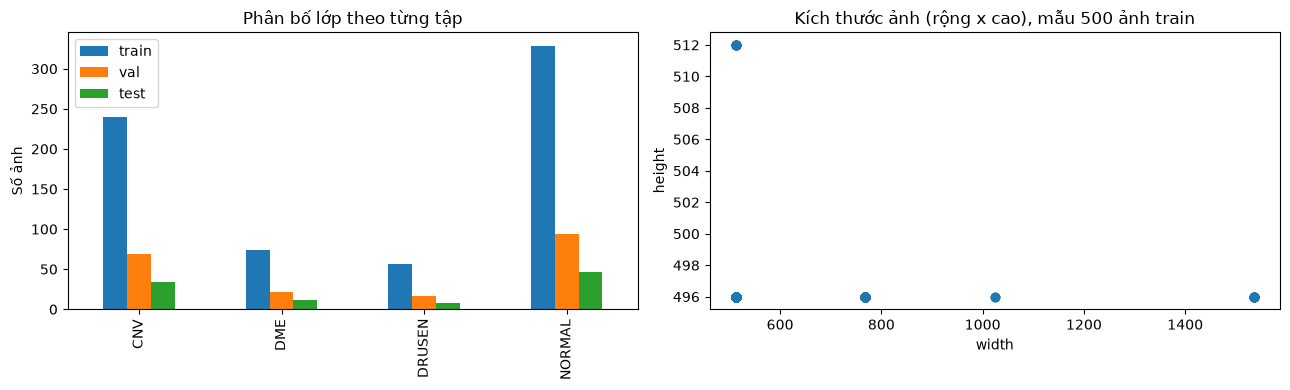

Tỉ lệ mất cân bằng (max/min) ở train: 5.77


In [6]:
# Phân bố lớp + thống kê kích thước ảnh
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
clean_summary.drop(index="TỔNG")[SPLITS].plot(kind="bar", ax=ax[0])
ax[0].set_title("Phân bố lớp theo từng tập"); ax[0].set_ylabel("Số ảnh")

rng = random.Random(SEED)
probe = rng.sample(clean["train"], min(500, len(clean["train"])))
sizes = np.array([Image.open(p).size for p, _ in probe])
ax[1].scatter(sizes[:, 0], sizes[:, 1], alpha=0.4)
ax[1].set_title("Kích thước ảnh (rộng x cao), mẫu 500 ảnh train")
ax[1].set_xlabel("width"); ax[1].set_ylabel("height")
plt.tight_layout(); plt.show()

train_counts = np.array([sum(1 for _, y in clean["train"] if y == i) for i in range(NUM_CLASSES)])
imb_ratio = train_counts.max() / max(train_counts.min(), 1)
print("Tỉ lệ mất cân bằng (max/min) ở train:", round(imb_ratio, 2))

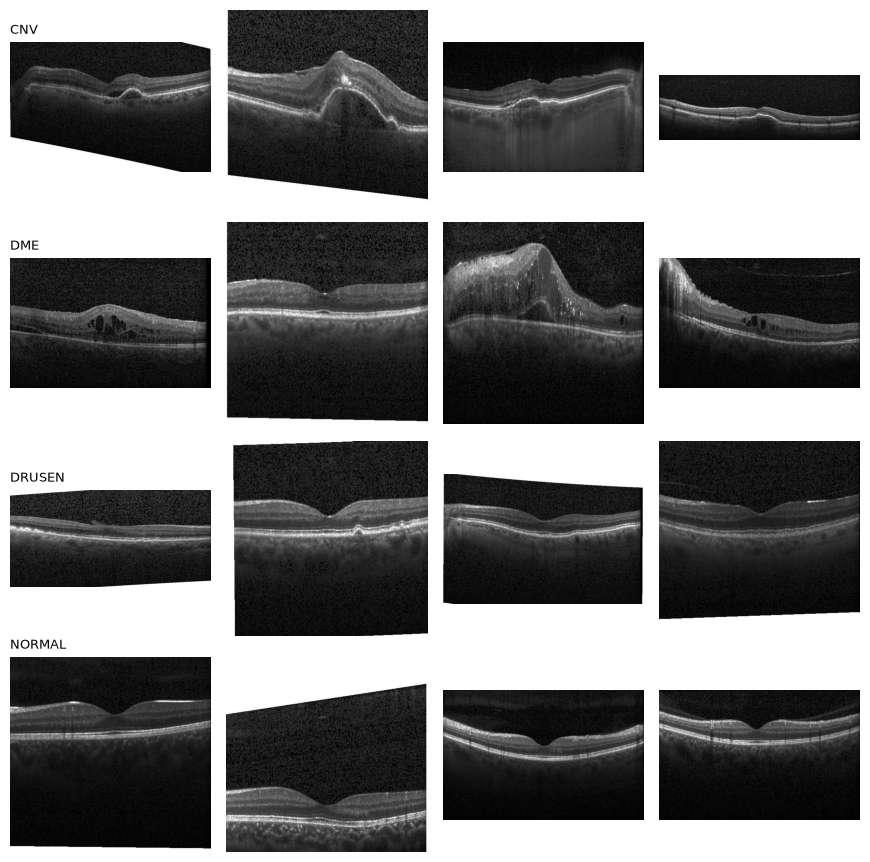

In [7]:
# Xem vài ảnh mẫu mỗi lớp
n_show = 4
fig, axes = plt.subplots(NUM_CLASSES, n_show, figsize=(2.2 * n_show, 2.2 * NUM_CLASSES), squeeze=False)
for ci, cname in enumerate(CLASS_NAMES):
    pool = [p for p, y in clean["train"] if y == ci]
    for j, p in enumerate(rng.sample(pool, min(n_show, len(pool)))):
        axes[ci][j].imshow(Image.open(p).convert("RGB")); axes[ci][j].axis("off")
        if j == 0: axes[ci][j].set_title(cname, fontsize=9, loc="left")
plt.tight_layout(); plt.show()

## 3. Tiền xử lý: Normalize + Augmentation

- **Resize** về `IMG_SIZE x IMG_SIZE` để mọi ảnh cùng kích thước.
- **Normalize** theo `mean` và `std` tính **chỉ trên tập train** (tránh rò rỉ thông tin từ val/test).
- **Augmentation chỉ áp dụng cho train**: lật ngang, xoay nhẹ, dịch chuyển, đổi độ sáng/tương phản. Val và test chỉ resize + normalize.

> ⚠️ Nếu dataset của nhóm nhạy cảm với phép lật (ví dụ chữ số, chữ cái, ảnh y tế có hướng cố định) thì hãy bỏ `RandomHorizontalFlip` ở bên dưới.

In [8]:
class ImageListDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples, self.transform = samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, y = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, y

# Tính mean/std trên tập train (chỉ resize + ToTensor)
base_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
stat_loader = DataLoader(ImageListDataset(clean["train"], base_tf), batch_size=128, num_workers=NUM_WORKERS)

n, s1, s2 = 0, torch.zeros(3), torch.zeros(3)
for x, _ in stat_loader:
    b = x.size(0)
    s1 += x.mean(dim=[2, 3]).sum(0)
    s2 += (x ** 2).mean(dim=[2, 3]).sum(0)
    n += b
MEAN = (s1 / n)
STD  = (s2 / n - MEAN ** 2).sqrt()
print("Mean:", MEAN.tolist()); print("Std :", STD.tolist())

Mean: [0.18974623084068298, 0.18974623084068298, 0.18974623084068298]
Std : [0.21449477970600128, 0.21449477970600128, 0.21449477970600128]


In [9]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
])

train_ds = ImageListDataset(clean["train"], train_tf)
val_ds   = ImageListDataset(clean["val"],   eval_tf)
test_ds  = ImageListDataset(clean["test"],  eval_tf)

g = torch.Generator(); g.manual_seed(SEED)
pin = DEVICE.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=pin, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=700  val=200  test=100


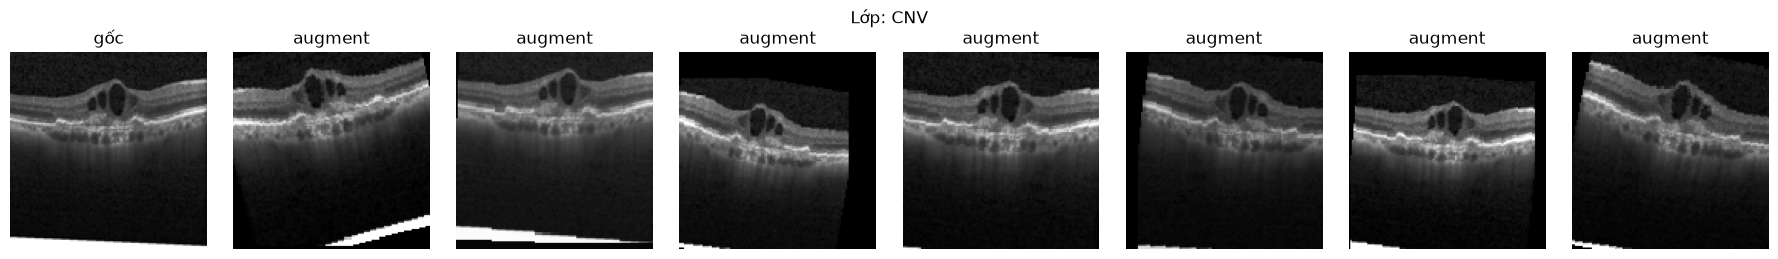

In [10]:
# Minh họa augmentation: 1 ảnh gốc và 7 phiên bản đã augment
def denorm(t):
    return (t * STD.view(3, 1, 1) + MEAN.view(3, 1, 1)).clamp(0, 1).permute(1, 2, 0).numpy()

p0, y0 = clean["train"][0]
orig = Image.open(p0).convert("RGB")
fig, axes = plt.subplots(1, 8, figsize=(18, 2.6))
axes[0].imshow(orig.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("gốc"); axes[0].axis("off")
for k in range(1, 8):
    axes[k].imshow(denorm(train_tf(orig))); axes[k].set_title("augment"); axes[k].axis("off")
plt.suptitle(f"Lớp: {CLASS_NAMES[y0]}"); plt.tight_layout(); plt.show()

## 4. Model 1 – Simple CNN

Kiến trúc đơn giản, tự thiết kế, chỉ gồm 3 loại lớp theo yêu cầu đề bài:

| Thành phần | Chi tiết |
|---|---|
| Conv block 1 | Conv2d(3→32, 3×3) → ReLU → MaxPool(2) |
| Conv block 2 | Conv2d(32→64, 3×3) → ReLU → MaxPool(2) |
| Conv block 3 | Conv2d(64→128, 3×3) → ReLU → MaxPool(2) |
| Fully connected | Flatten → Linear(→256) → ReLU → Dropout(0.5) → Linear(→số lớp) |

Không dùng BatchNorm hay skip-connection để giữ mô hình ở mức "simple", làm mốc so sánh với Model 2 (CNN phức tạp) và Model 3 (Transfer Learning).

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, img_size=128, in_ch=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),    nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),   nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1, in_ch, img_size, img_size)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(NUM_CLASSES, IMG_SIZE).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTổng số tham số: {n_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)

Tổng số tham số: 8,483,140


## 5. Huấn luyện

- Loss: `CrossEntropyLoss` (có trọng số lớp nếu dữ liệu mất cân bằng).
- Optimizer: `Adam` + weight decay nhỏ.
- `ReduceLROnPlateau` giảm learning rate khi `val_loss` chững lại.
- **Early stopping** và lưu checkpoint tốt nhất theo `val_loss`.

In [12]:
if USE_CLASS_WEIGHTS and imb_ratio > 1.5:
    w = train_counts.sum() / (NUM_CLASSES * np.maximum(train_counts, 1))
    class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
    print("Dùng class weights:", np.round(w, 3))
else:
    class_weights = None
    print("Dữ liệu tương đối cân bằng -> không dùng class weights")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def run_epoch(loader, train=False):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val, best_state, wait = float("inf"), None, 0
CKPT = OUT_DIR / "model1_simple_cnn.pt"

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)
    lr_now = optimizer.param_groups[0]["lr"]
    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, lr_now]): history[k].append(v)

    flag = ""
    if va_loss < best_val - 1e-4:
        best_val, wait = va_loss, 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"model": best_state, "classes": CLASS_NAMES, "img_size": IMG_SIZE,
                    "mean": MEAN.tolist(), "std": STD.tolist()}, CKPT)
        flag = "  <-- best"
    else:
        wait += 1
    print(f"Epoch {epoch:02d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | lr {lr_now:.1e}{flag}")
    if wait >= PATIENCE:
        print(f"Early stopping tại epoch {epoch}"); break

train_time = time.time() - t0
print(f"\nThời gian huấn luyện: {train_time/60:.1f} phút | best val_loss = {best_val:.4f}")
model.load_state_dict(best_state)

Dùng class weights: [0.729 2.365 3.07  0.532]
Epoch 01/30 | train loss 1.4998 acc 0.2571 | val loss 1.3692 acc 0.3450 | lr 1.0e-03  <-- best
Epoch 02/30 | train loss 1.3833 acc 0.4214 | val loss 1.3636 acc 0.4500 | lr 1.0e-03  <-- best
Epoch 03/30 | train loss 1.3719 acc 0.3529 | val loss 1.3451 acc 0.4400 | lr 1.0e-03  <-- best
Epoch 04/30 | train loss 1.3727 acc 0.3914 | val loss 1.3579 acc 0.3150 | lr 1.0e-03
Epoch 05/30 | train loss 1.3633 acc 0.3000 | val loss 1.3428 acc 0.4900 | lr 1.0e-03  <-- best
Epoch 06/30 | train loss 1.3370 acc 0.4343 | val loss 1.3258 acc 0.4150 | lr 1.0e-03  <-- best
Epoch 07/30 | train loss 1.3413 acc 0.3486 | val loss 1.2696 acc 0.5950 | lr 1.0e-03  <-- best
Epoch 08/30 | train loss 1.3328 acc 0.5271 | val loss 1.2621 acc 0.5600 | lr 1.0e-03  <-- best
Epoch 09/30 | train loss 1.2783 acc 0.4557 | val loss 1.2501 acc 0.4850 | lr 1.0e-03  <-- best
Epoch 10/30 | train loss 1.2599 acc 0.5129 | val loss 1.1075 acc 0.6600 | lr 1.0e-03  <-- best
Epoch 11/30 | 

<All keys matched successfully>

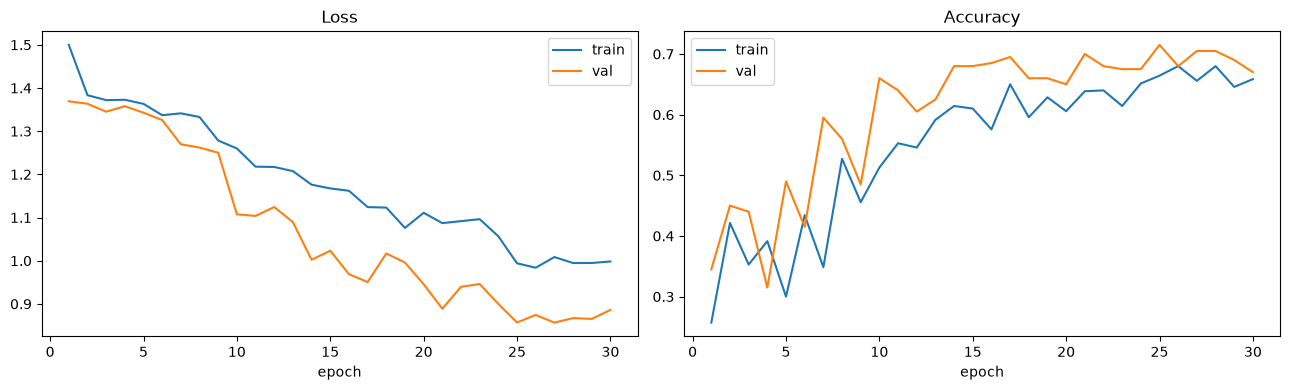

In [13]:
# Đường cong học (learning curves)
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ep, history["train_loss"], label="train"); ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, history["train_acc"], label="train"); ax[1].plot(ep, history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "model1_curves.png", dpi=150); plt.show()

## 6. Đánh giá trên tập test

Các metric sử dụng:
- **Accuracy**: tỉ lệ dự đoán đúng tổng thể.
- **Precision / Recall / F1** theo từng lớp, cùng **macro-F1** (trung bình các lớp, không bị lấn át bởi lớp lớn) và **weighted-F1**.
- **Confusion matrix** để xem các lớp hay bị nhầm với nhau.

In [14]:
@torch.no_grad()
def predict(loader):
    model.eval()
    ys, ps, probs = [], [], []
    for x, y in loader:
        out = model(x.to(DEVICE))
        probs.append(F.softmax(out, 1).cpu().numpy())
        ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

y_true, y_pred, y_prob = predict(test_loader)

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
_, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test accuracy : {acc:.4f}")
print(f"Macro precision/recall/F1: {p_macro:.4f} / {r_macro:.4f} / {f1_macro:.4f}")
print(f"Weighted F1   : {f1_weighted:.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

Test accuracy : 0.6200
Macro precision/recall/F1: 0.5286 / 0.5260 / 0.5082
Weighted F1   : 0.6621

              precision    recall  f1-score   support

         CNV     0.8000    0.7059    0.7500        34
         DME     0.2857    0.3636    0.3200        11
      DRUSEN     0.1429    0.3750    0.2069         8
      NORMAL     0.8857    0.6596    0.7561        47

    accuracy                         0.6200       100
   macro avg     0.5286    0.5260    0.5082       100
weighted avg     0.7311    0.6200    0.6621       100



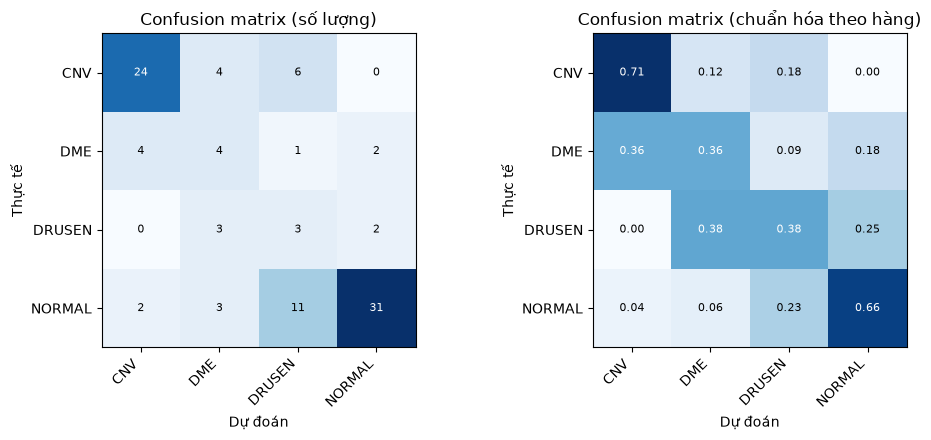

In [15]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(1, 2, figsize=(max(10, NUM_CLASSES * 1.6), max(4.5, NUM_CLASSES * 0.7)))
for a, M, title, fmt in [(ax[0], cm, "Confusion matrix (số lượng)", "d"),
                         (ax[1], cm_norm, "Confusion matrix (chuẩn hóa theo hàng)", ".2f")]:
    im = a.imshow(M, cmap="Blues")
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(CLASS_NAMES, rotation=45, ha="right"); a.set_yticklabels(CLASS_NAMES)
    a.set_xlabel("Dự đoán"); a.set_ylabel("Thực tế"); a.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, format(M[i, j], fmt), ha="center", va="center",
                   color="white" if M[i, j] > M.max() / 2 else "black", fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "model1_confusion_matrix.png", dpi=150); plt.show()

Số ảnh dự đoán sai: 38/100


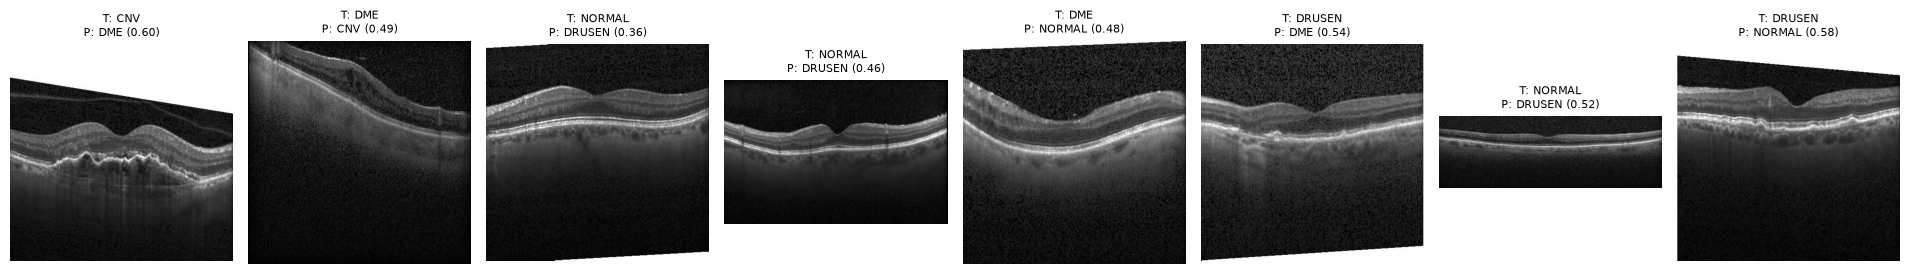

In [16]:
# Một số ảnh bị dự đoán sai (kèm độ tin cậy)
wrong = np.where(y_true != y_pred)[0]
print(f"Số ảnh dự đoán sai: {len(wrong)}/{len(y_true)}")
if len(wrong):
    pick = rng.sample(list(wrong), min(8, len(wrong)))
    fig, axes = plt.subplots(1, len(pick), figsize=(2.4 * len(pick), 3), squeeze=False)
    for a, idx in zip(axes[0], pick):
        a.imshow(Image.open(clean["test"][idx][0]).convert("RGB")); a.axis("off")
        a.set_title(f"T: {CLASS_NAMES[y_true[idx]]}\nP: {CLASS_NAMES[y_pred[idx]]} ({y_prob[idx].max():.2f})",
                    fontsize=8)
    plt.tight_layout(); plt.show()

## 7. Lưu kết quả để so sánh với Model 2 và Model 3

In [17]:
results = {
    "model": "Model 1 - Simple CNN",
    "params": int(n_params),
    "img_size": IMG_SIZE,
    "epochs_run": len(history["train_loss"]),
    "train_time_min": round(train_time / 60, 2),
    "best_val_loss": float(best_val),
    "test_accuracy": float(acc),
    "test_macro_precision": float(p_macro),
    "test_macro_recall": float(r_macro),
    "test_macro_f1": float(f1_macro),
    "test_weighted_f1": float(f1_weighted),
    "classes": CLASS_NAMES,
}
with open(OUT_DIR / "model1_metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
pd.DataFrame(history).to_csv(OUT_DIR / "model1_history.csv", index=False)
pd.Series(results).to_frame("Model 1")

,Model 1
model,Model 1 - Simple CNN
params,8483140
img_size,128
epochs_run,30
train_time_min,0.5
best_val_loss,0.856631
test_accuracy,0.62
test_macro_precision,0.528571
test_macro_recall,0.526023
test_macro_f1,0.508249


### Nhận xét (điền sau khi chạy)

- **Kết quả**: Accuracy / macro-F1 trên test là bao nhiêu? Lớp nào tốt nhất, lớp nào kém nhất?
- **Overfitting?** So sánh đường cong train và val: khoảng cách loss/accuracy có lớn không? Augmentation và dropout có giúp được không?
- **Hạn chế của Simple CNN**: ít tầng, không có BatchNorm, khó nắm bắt đặc trưng phức tạp → là cơ sở để cải tiến ở **Model 2** (CNN phức tạp với các CNN block) và **Model 3** (Transfer Learning / Fine-tuning).